# Phase 4 - Machine Learning

I will be applying the machine learning models we learned in class to the survey data I collected. This is the 4th phase of the project. I'm going to start by cleaning the data and doing some encoding. Then I will train a baseline model, try a Random Forest, and look at which features are the most important. Lastly, I will test out regression and clustering just to see the results.

First, I need to read the CSV file. After that I will clean the data because some people wrote weird things in the survey, and then I will set up the target variable (high vs low productivity). Once the data is ready, I will use `pd.get_dummies` to encode the categorical variables and test a few models with cross validation. Finally, I will tune the best model and evaluate it.

In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor


In [81]:
data_path = 'dataset/Blank Quiz.csv'
df_raw = pd.read_csv(data_path)

print('Original data shape:', df_raw.shape)

print('Number of columns initially:', len(df_raw.columns))
df_raw.head()

Original data shape: (150, 41)
Number of columns initially: 41


,Timestamp,Total score,What is your current year of study?,What is your current year of study? [Score],What is your current year of study? [Feedback],What is your department?,What is your department? [Score],What is your department? [Feedback],"On average, how many hours do you study per day?","On average, how many hours do you study per day? [Score]",...,What is your current GPA range? [Feedback],How many hours of sleep did you get last night (or on average)? (Only numbers),How many hours of sleep did you get last night (or on average)? (Only numbers) [Score],How many hours of sleep did you get last night (or on average)? (Only numbers) [Feedback],What is your average daily phone screen time (in hours)? (Only numbers),What is your average daily phone screen time (in hours)? (Only numbers) [Score],What is your average daily phone screen time (in hours)? (Only numbers) [Feedback],How would you rate your current stress level this semester?,How would you rate your current stress level this semester? [Score],How would you rate your current stress level this semester? [Feedback]
0,2026/04/01 04:32:00 PM GMT+3,0.00 / 0,3rd year,-- / 0,NaN,Business,-- / 0,NaN,0-2 hours,-- / 0,...,NaN,9,-- / 0,NaN,6,-- / 0,NaN,6,-- / 0,NaN
1,2026/04/09 12:12:00 PM GMT+3,0.00 / 0,4th year,-- / 0,NaN,Psychology,-- / 0,NaN,6+ hours,-- / 0,...,NaN,9,-- / 0,NaN,4,-- / 0,NaN,6,-- / 0,NaN
2,2026/04/08 04:42:00 PM GMT+3,0.00 / 0,3rd year,-- / 0,NaN,Psychology,-- / 0,NaN,6+ hours,-- / 0,...,NaN,8,-- / 0,NaN,2,-- / 0,NaN,7,-- / 0,NaN
3,2026/04/07 03:59:00 PM GMT+3,0.00 / 0,3rd year,-- / 0,NaN,Design,-- / 0,NaN,0-2 hours,-- / 0,...,NaN,9,-- / 0,NaN,8,-- / 0,NaN,5,-- / 0,NaN
4,2026/04/13 06:49:00 PM GMT+3,0.00 / 0,4th year,-- / 0,NaN,Computer Science,-- / 0,NaN,6+ hours,-- / 0,...,NaN,9,-- / 0,NaN,8,-- / 0,NaN,6,-- / 0,NaN


### Finding the actual questions

Google Forms adds score and feedback columns that I don't really need. Also the column names are the entire questions, so I will shorten them to make writing code easier later.

In [82]:
# I'm going to grab only the columns that actually contain answers
# (skipping the Google forms score/feedback ones)
answer_cols = []
for c in df_raw.columns:
    c_lower = c.lower()
    if '[score]' not in c_lower and '[feedback]' not in c_lower:
        answer_cols.append(c)

df = df_raw[answer_cols].copy()
print('Data shape after removing the useless score and feedback columns:', df.shape)

Data shape after removing the useless score and feedback columns: (150, 15)


In [83]:
# Now I need to rename those super long questions into simple column names.
rename_dict = {}

for col in df.columns:
    col_str = col.lower()
    
    if 'timestamp' in col_str:
        rename_dict[col] = 'timestamp'
    elif 'year of study' in col_str:
        rename_dict[col] = 'year'
    elif 'department' in col_str:
        rename_dict[col] = 'department'
    elif 'hours do you study per day' in col_str:
        rename_dict[col] = 'study_hours'
    elif 'primarily study' in col_str:
        rename_dict[col] = 'location'
    elif 'typical noise level' in col_str:
        rename_dict[col] = 'noise_level'
    elif 'listen to audio/music' in col_str:
        rename_dict[col] = 'audio'
    elif 'alone or with others' in col_str:
        rename_dict[col] = 'social'
    elif 'level of focus' in col_str:
        rename_dict[col] = 'focus'
    elif 'productive do you feel' in col_str:
        rename_dict[col] = 'productivity'
    elif 'gpa range' in col_str:
        rename_dict[col] = 'gpa'
    elif 'hours of sleep' in col_str:
        rename_dict[col] = 'sleep'
    elif 'phone screen time' in col_str:
        rename_dict[col] = 'screen_time'
    elif 'stress level' in col_str:
        rename_dict[col] = 'stress'

# Apply the new names
df = df.rename(columns=rename_dict)

# Reorder columns to just the ones we named
final_cols = list(rename_dict.values())
df = df[final_cols].copy()

print('Simplified column names:')
print(df.columns.tolist())
df.head(3)

Simplified column names:
['timestamp', 'year', 'department', 'study_hours', 'location', 'noise_level', 'audio', 'social', 'focus', 'productivity', 'gpa', 'sleep', 'screen_time', 'stress']


,timestamp,year,department,study_hours,location,noise_level,audio,social,focus,productivity,gpa,sleep,screen_time,stress
0,2026/04/01 04:32:00 PM GMT+3,3rd year,Business,0-2 hours,Puplic study area,3,"Yes, Lyrical (Pop, Rock)",Alone,8,7,3.0-3.5,9,6,6
1,2026/04/09 12:12:00 PM GMT+3,4th year,Psychology,6+ hours,Home,2,"Yes, Lyrical (Pop, Rock)",With friends,6,7,3.0-3.5,9,4,6
2,2026/04/08 04:42:00 PM GMT+3,3rd year,Psychology,6+ hours,Puplic study area,2,"Yes, Other",Alone,8,7,3.5-4.0,8,2,7


In [84]:
# Cleaning up the text columns to remove extra spaces
cat_cols = ['year', 'department', 'study_hours', 'location', 'audio', 'social', 'gpa']
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()

# I noticed this typo when exploring the data earlier, so fixing it here
df['location'] = df['location'].replace({'Puplic study area': 'Public study area'})

# Converting columns that should be numbers
num_cols = ['noise_level', 'focus', 'productivity', 'sleep', 'screen_time', 'stress']
for num in num_cols:
    df[num] = pd.to_numeric(df[num], errors='coerce')

print("Checking data types so I can see if the numeric conversion worked:")
print(df[num_cols].dtypes)

print("\nMissing values:")
print(df.isna().sum())

Checking data types so I can see if the numeric conversion worked:
noise_level     int64
focus           int64
productivity    int64
sleep           int64
screen_time     int64
stress          int64
dtype: object

Missing values:
timestamp       0
year            0
department      0
study_hours     0
location        0
noise_level     0
audio           0
social          0
focus           0
productivity    0
gpa             0
sleep           0
screen_time     0
stress          0
dtype: int64


In [85]:
# I can't really train a model if a row is missing the answer for important questions.
# Specifying the critical columns to drop NAs from.
key_cols = [
    'year', 'department', 'study_hours', 'location', 'audio', 'social', 'gpa',
    'noise_level', 'focus', 'productivity', 'sleep', 'screen_time', 'stress'
]

rows_before = df.shape[0]

# Drop missing values
df = df.dropna(subset=key_cols).copy()
rows_after = df.shape[0]

print('Number of rows before cleaning missing values:', rows_before)
print('Number of rows after cleaning missing values:', rows_after)
print('I lost about', rows_before - rows_after, 'rows because they had missing answers.')

Number of rows before cleaning missing values: 150
Number of rows after cleaning missing values: 150
I lost about 0 rows because they had missing answers.


Here is how many productive vs non-productive students I have:
productivity_high
1    78
0    72
Name: count, dtype: int64


C:\Users\kosot\AppData\Local\Temp\ipykernel_15740\304155644.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='productivity_high', palette='Set2')


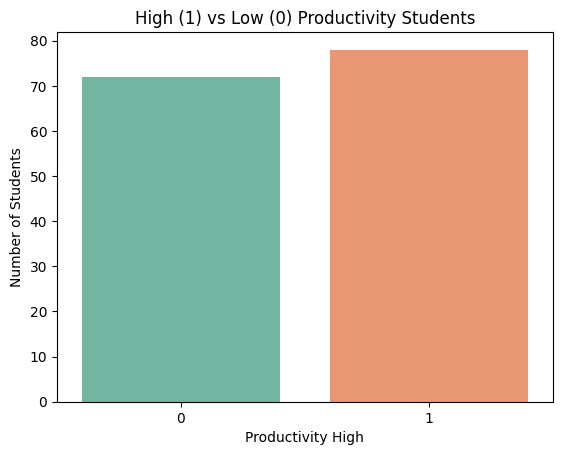

In [86]:
# Creating my target columns. If productivity is >= 7, they are productive (1). Otherwise 0.
df['productivity_high'] = (df['productivity'] >= 7).astype(int)

# Same idea for focus score
df['focus_high'] = (df['focus'] >= 7).astype(int)

print('Here is how many productive vs non-productive students I have:')
print(df['productivity_high'].value_counts(dropna=False))

# Quick plot to visualize the class balance (important step from the recitations)
plt.figure()
sns.countplot(data=df, x='productivity_high', palette='Set2')
plt.title('High (1) vs Low (0) Productivity Students')
plt.xlabel('Productivity High')
plt.ylabel('Number of Students')
plt.show()

In [87]:
# Separating my data into features (X) and target (y)
# I need to make sure I don't include focus and productivity columns in X, otherwise it's basically cheating
X_columns = [
    'year', 'department', 'study_hours', 'location', 'audio', 'social', 'gpa',
    'noise_level', 'sleep', 'screen_time', 'stress'
]

X = df[X_columns].copy()
y = df['productivity_high'].copy()

# Encoding categorical variables with get_dummies, like we were shown in class
X_encoded = pd.get_dummies(X, drop_first=True)

# Train Test spliiting: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Scaling the data so Logistic Regression works properly (StandardScaler)
# Doing this after the split so we don't accidentally leak test data into the training process!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Turning them back into DataFrames just to keep the column names (helps with feature importance later)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('My training data has this many rows and columns:', X_train.shape)
print('My test data has this many rows and columns: ', X_test.shape)


My training data has this many rows and columns: (120, 30)
My test data has this many rows and columns:  (30, 30)


### Preparing the Data for Machine Learning

Now I will create my `X` and `y` sets. Just like we learned, we use `pd.get_dummies` to one-hot encode categorical features, and split the data into train and test sets to evaluate the models later.

In [88]:
# I am trying three different models we learned in class:
# 1. Logistic Regression
# 2. Decision Tree
# 3. Random Forest (using 300 trees to start)

model_lr = LogisticRegression(max_iter=2000, random_state=42)
model_dt = DecisionTreeClassifier(random_state=42)
model_rf = RandomForestClassifier(random_state=42, n_estimators=300)

models_list = [
    ('Logistic Regression', model_lr),
    ('Decision Tree', model_dt),
    ('Random Forest', model_rf)
]

# I will use a KFold of 5 splits to average my scores and see which of the 3 performs best.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### Model Comparison with Cross Validation

In this part, I will train 3 different classification models (Logistic Regression, Decision Tree, Random Forest) and check their 5-fold Cross-Validation scores (Accuracy, Precision, Recall, F1, ROC-AUC) so I can pick the best one before moving on to the test set.

In [ ]:
# Empty list to store the scores I get from cross-validation
results = []

for name, model in models_list:
    print('Now training:', name)
    
    accs = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    precs = cross_val_score(model, X_train, y_train, cv=kf, scoring='precision')
    recs = cross_val_score(model, X_train, y_train, cv=kf, scoring='recall')
    f1s = cross_val_score(model, X_train, y_train, cv=kf, scoring='f1')
    aucs = cross_val_score(model, X_train, y_train, cv=kf, scoring='roc_auc')
    
    # taking the average (mean) of the 5 cross validation splits
    res_dict = {
        'Model': name,
        'Accuracy': round(accs.mean(), 4),
        'Precision': round(precs.mean(), 4),
        'Recall': round(recs.mean(), 4),
        'F1 Score': round(f1s.mean(), 4),
        'ROC AUC': round(aucs.mean(), 4)
    }
    
    results.append(res_dict)

# Looking at the results inside a dataframe
df_results = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print('\nHere is how they compared:')
print(df_results)

Now training: Logistic Regression
Now training: Decision Tree
Now training: Random Forest

Here is how they compared:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.6250     0.6458  0.6059    0.6230   0.6765
1        Random Forest    0.6250     0.6458  0.6059    0.6230   0.7103
2        Decision Tree    0.5917     0.6052  0.5833    0.5911   0.5873


### Hyperparameter Tuning

Because Random Forest performed the best on CV, I will now use `RandomizedSearchCV` to find the best hyperparameters (like n_estimators, max_depth, etc.) for it. I am using RandomizedSearchCV because it is quite a bit faster than checking every single combination in GridSearchCV.

In [90]:
# Random forest clearly won, so I will tune the RandomForestClassifier
rf_tune = RandomForestClassifier(random_state=42)

# Here are the numbers I want to mix and match to find the best settings
# (number of trees, how deep they go, splits, etc)
grid_of_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 3, 5, 8, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# RandomizedSearchCV instead of GridSearch because I don't want to check every single combination (too slow!)
random_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=grid_of_params,
    n_iter=15, # Try 15 random combinations
    scoring='f1',
    cv=5, # 5 fold again
    random_state=42
)

# This might take a little while to run...
random_search.fit(X_train, y_train)

# I can see what the best CV score was and what combination of numbers achieved it
print('The best F1 score we got in CV was:', round(random_search.best_score_, 4))
print('\nThe best settings discovered were:')
print(random_search.best_params_)

# Now that we know the best one, we save it as my final model for Random Forest
my_best_model = random_search.best_estimator_

The best F1 score we got in CV was: 0.6771

The best settings discovered were:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


In [91]:
# The final test! Applying the best tuned model to the 20% test data I hid earlier
test_predictions = my_best_model.predict(X_test)
test_probabilities = my_best_model.predict_proba(X_test)[:, 1] # getting probabilities to draw ROC curve later

# Same metrics as before
acc_test = accuracy_score(y_test, test_predictions)
prec_test = precision_score(y_test, test_predictions)
rec_test = recall_score(y_test, test_predictions)
f1_test = f1_score(y_test, test_predictions)
auc_test = roc_auc_score(y_test, test_probabilities)

print('--- Test Data Performance ---')
print('Accuracy on Test Set:', round(acc_test, 4))
print('Precision on Test Set:', round(prec_test, 4))
print('Recall on Test Set:', round(rec_test, 4))
print('F1 on Test Set:', round(f1_test, 4))
print('AUC on Test Set:', round(auc_test, 4))

print('\nFull Classification Report that sklearn gives us:')
print(classification_report(y_test, test_predictions, digits=4))

--- Test Data Performance ---
Accuracy on Test Set: 0.7
Precision on Test Set: 0.7857
Recall on Test Set: 0.6471
F1 on Test Set: 0.7097
AUC on Test Set: 0.7692

Full Classification Report that sklearn gives us:
              precision    recall  f1-score   support

           0     0.6250    0.7692    0.6897        13
           1     0.7857    0.6471    0.7097        17

    accuracy                         0.7000        30
   macro avg     0.7054    0.7081    0.6997        30
weighted avg     0.7161    0.7000    0.7010        30



Confusion Matrix Matrix:
 [[10  3]
 [ 6 11]]


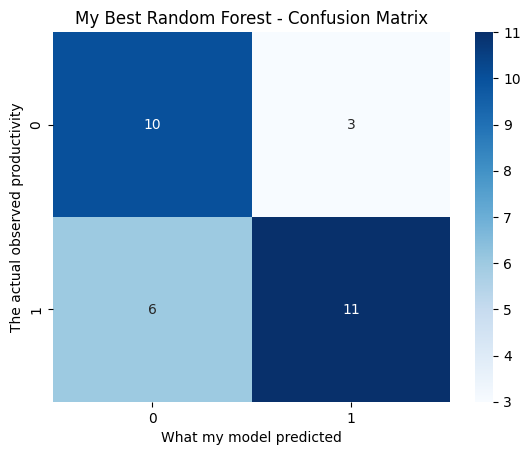

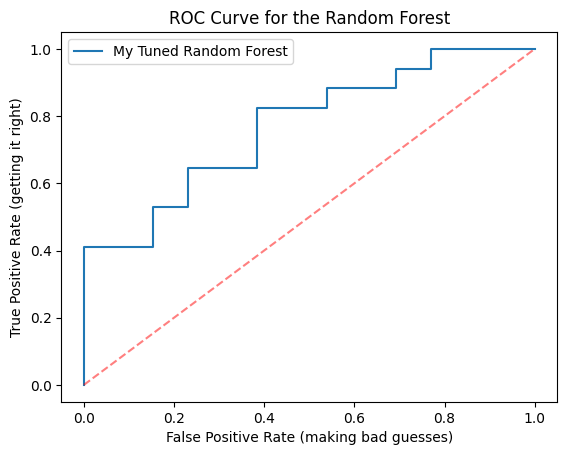

In [92]:
# Visualizing the True positives and false positives using a confusion matrix
cm_results = confusion_matrix(y_test, test_predictions)

print('Confusion Matrix Matrix:\n', cm_results)

# making it look nice with seaborn heatmap
plt.figure()
sns.heatmap(cm_results, annot=True, fmt='d', cmap='Blues')
plt.title('My Best Random Forest - Confusion Matrix')
plt.xlabel('What my model predicted')
plt.ylabel('The actual observed productivity')
plt.show()

# Receiver Operating Characteristic Curve (ROC)
# I calculate false positive rate and true positive rate like in class
false_pr, true_pr, thresholds_roc = roc_curve(y_test, test_probabilities)

plt.figure()
plt.plot(false_pr, true_pr, label='My Tuned Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', alpha=0.5) # this is a random guessing 'baseline' line
plt.xlabel('False Positive Rate (making bad guesses)')
plt.ylabel('True Positive Rate (getting it right)')
plt.title('ROC Curve for the Random Forest')
plt.legend()
plt.show()

The top features that make a student productive:
                          Feature  Importance Weight
0                     noise_level           0.195511
1                          stress           0.105411
2                           sleep           0.104026
3                     screen_time           0.075767
4                location_Library           0.036474
5           study_hours_4-6 hours           0.031101
6                   year_3rd year           0.029047
7           study_hours_2-4 hours           0.023798
8  audio_Yes, Lyrical (Pop, Rock)           0.023475
9      location_Public study area           0.023108


C:\Users\kosot\AppData\Local\Temp\ipykernel_15740\3203834714.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=important_features.head(10), x='Importance Weight', y='Feature', palette='magma')


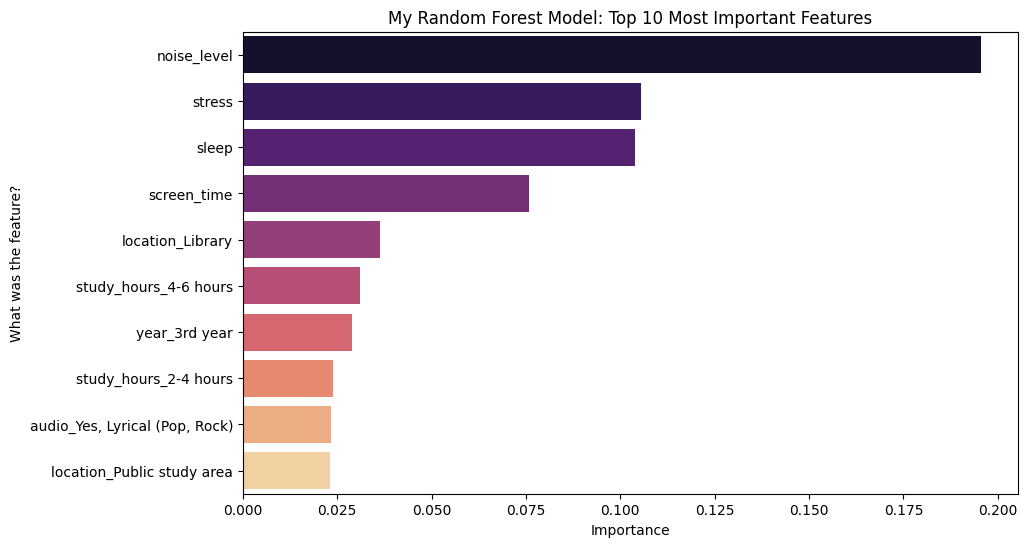

In [93]:
# What was actually the most important factor in whether someone was productive?
feature_names_list = list(X_train.columns)
feature_weights = my_best_model.feature_importances_

# Sticking them together side by side using a quick dictionary
important_features = pd.DataFrame({
    'Feature': feature_names_list,
    'Importance Weight': feature_weights
})

# Sorting from highest importance to lowest
important_features = important_features.sort_values('Importance Weight', ascending=False).reset_index(drop=True)

print('The top features that make a student productive:')
print(important_features.head(10))

# Make it pretty to put in a slide for the presentation!
plt.figure(figsize=(10, 6))
sns.barplot(data=important_features.head(10), x='Importance Weight', y='Feature', palette='magma')
plt.title('My Random Forest Model: Top 10 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('What was the feature?')
plt.show()

### Trying Regression (Focus Score)

As an extra step, I am going to try regression by predicting `focus` as a continuous score instead of treating it as a categorical high/low thing like I did for productivity.

In [94]:
# What if I wanted to actually predict the exact 1-10 focus score instead of just 'did they focus or not'?
target_focus_score = df['focus'].copy()

# Need to encode variables again but this time I'm skipping the old target columns obviously
X_categorical_focus = df[X_columns].copy()
X_focus_encoded = pd.get_dummies(X_categorical_focus, drop_first=True)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_focus_encoded, target_focus_score, test_size=0.2, random_state=42
)

# RandomForestRegressor (so I predict a continuous number, not 0/1 classes)
regression_forest = RandomForestRegressor(random_state=42, n_estimators=300)
regression_forest.fit(X_train_r, y_train_r)

focus_predictions = regression_forest.predict(X_test_r)

# Evaluation metrics for regression: MAE, RMSE, R^2
mae_val = mean_absolute_error(y_test_r, focus_predictions)
mse_val = mean_squared_error(y_test_r, focus_predictions)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_test_r, focus_predictions)

print('--- Continuous Score Prediction Results ---')
print('On average, I was off by this many focus points (MAE):', round(mae_val, 4))
print('Root Mean Squared Error (RMSE) is:', round(rmse_val, 4))
print('My R-squared score (closer to 1 is better) is:', round(r2_val, 4))

--- Continuous Score Prediction Results ---
On average, I was off by this many focus points (MAE): 0.7469
Root Mean Squared Error (RMSE) is: 0.9192
My R-squared score (closer to 1 is better) is: 0.5431
